<a href="https://colab.research.google.com/github/deebuls/devblog/blob/main/posts/notebooks/2025-07-24-Image-Projection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
title: "Image 2D to 3D projection"
author: "Deebul Nair"
badges: true
date: "2025-07-24"
description: "Different aspects of projecting 2D point of image to 3D point"

---


# From Pixels to the Real World: A Camera Vision Story 📸

*A journey through computer vision: How cameras see the world and how we can see it back*

---

## Chapter 1: The Mystery of the Missing Dimension

Imagine you're looking at a photo on your phone. You see a bird flying in the sky. But here's the puzzle: **where exactly is that bird in the real world?**

Your photo is flat - it only has width and height. But the real world has depth too. So how do we figure out how far away things really are?



In [2]:

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Let's start our story...
print("🔍 The Great 3D Mystery Begins!")



🔍 The Great 3D Mystery Begins!


---

## Chapter 2: Meet the Camera Matrix

Every camera has a secret code. We call it the **K matrix**. Think of it as the camera's DNA - it tells us how the camera sees the world.


In [3]:
# This is what a typical camera matrix looks like
K = np.array([
    [800,   0, 320],  # fx = focal length in x, cx = center x
    [  0, 800, 240],  # fy = focal length in y, cy = center y
    [  0,   0,   1]   # Always ends with [0, 0, 1]
])

print("📷 Camera Matrix (K):")
print(K)
print("\nWhat this means:")
print("• fx, fy = 800: How 'zoomed in' the camera is")
print("• cx, cy = 320, 240: The center of the image")

📷 Camera Matrix (K):
[[800   0 320]
 [  0 800 240]
 [  0   0   1]]

What this means:
• fx, fy = 800: How 'zoomed in' the camera is
• cx, cy = 320, 240: The center of the image



---

## Chapter 3: The Problem - One Photo, Infinite Possibilities

Here's the tricky part. When you see a point in a photo, it could be anywhere along a line in 3D space!

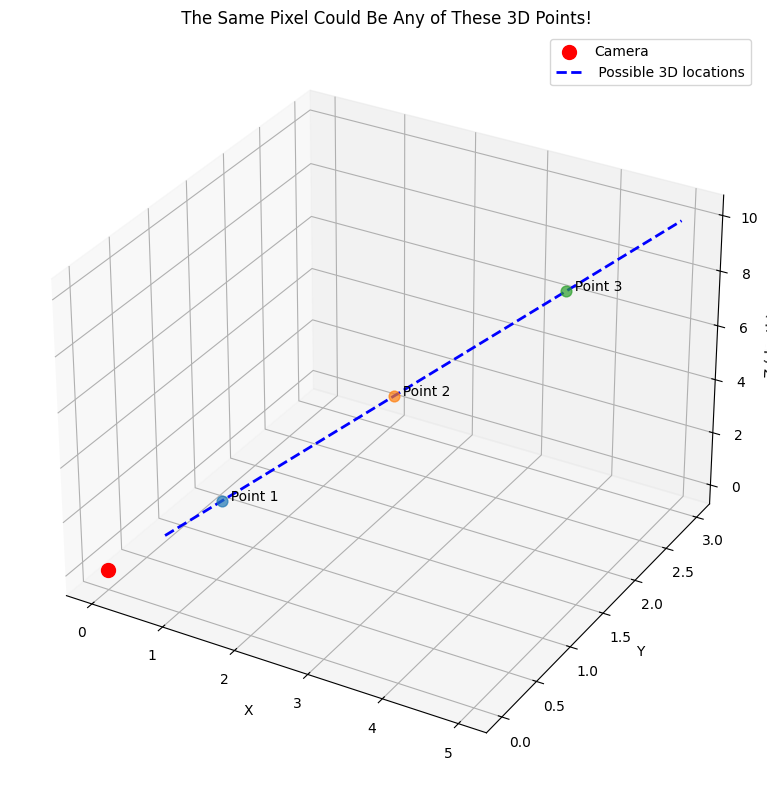

The mystery: One 2D point = Many possible 3D locations!


In [5]:
# Let's visualize this problem
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Camera at origin
camera = np.array([0, 0, 0])
ax.scatter(*camera, color='red', s=100, label='Camera')

# A ray going into the scene
t_values = np.linspace(1, 10, 50)
ray_x = t_values * 0.5
ray_y = t_values * 0.3
ray_z = t_values

ax.plot(ray_x, ray_y, ray_z, 'b--', linewidth=2, label=' Possible 3D locations')

# Show some example points on the ray
for i, t in enumerate([2, 5, 8]):
    x, y, z = t * 0.5, t * 0.3, t
    ax.scatter(x, y, z, s=60, alpha=0.7)
    ax.text(x, y, z, f'  Point {i+1}', fontsize=10)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z (depth)')
ax.legend()
ax.set_title(' The Same Pixel Could Be Any of These 3D Points!')
plt.tight_layout()
plt.show()

print("The mystery: One 2D point = Many possible 3D locations!")

---

## Chapter 4: Solution 1 - When We Know the Distance

Sometimes we get lucky! If we know how far away something is, we can solve the puzzle.


Success! The 3D point is at:
   X = 0.50 meters
   Y = 0.38 meters
   Z = 5.00 meters


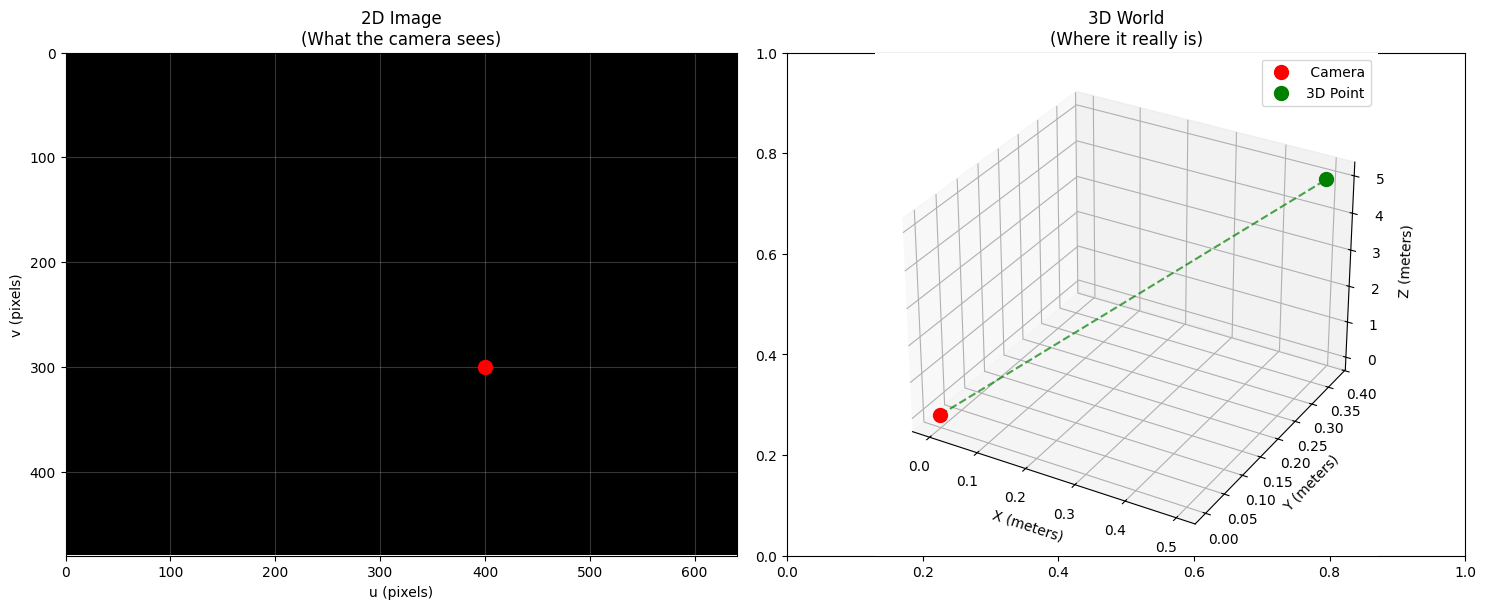

In [6]:
def pixel_to_3d_with_depth(u, v, Z, K):
    """Convert a 2D pixel to 3D when we know the depth"""
    fx, fy = K[0,0], K[1,1]
    cx, cy = K[0,2], K[1,2]

    # The magic formula!
    X = (u - cx) * Z / fx
    Y = (v - cy) * Z / fy

    return X, Y, Z

# Let's try it!
pixel_u, pixel_v = 400, 300  # A point in our image
depth_Z = 5.0  # We somehow know it's 5 meters away

X, Y, Z = pixel_to_3d_with_depth(pixel_u, pixel_v, depth_Z, K)

print(f"Success! The 3D point is at:")
print(f"   X = {X:.2f} meters")
print(f"   Y = {Y:.2f} meters")
print(f"   Z = {Z:.2f} meters")

# Let's visualize this
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Show the 2D image
ax1.imshow(np.zeros((480, 640)), cmap='gray')
ax1.plot(pixel_u, pixel_v, 'ro', markersize=10)
ax1.set_xlim(0, 640)
ax1.set_ylim(480, 0)
ax1.set_title('2D Image\n(What the camera sees)')
ax1.set_xlabel('u (pixels)')
ax1.set_ylabel('v (pixels)')
ax1.grid(True, alpha=0.3)

# Show the 3D result
ax2 = plt.subplot(122, projection='3d')
ax2.scatter(0, 0, 0, color='red', s=100, label=' Camera')
ax2.scatter(X, Y, Z, color='green', s=100, label='3D Point')
ax2.plot([0, X], [0, Y], [0, Z], 'g--', alpha=0.7)
ax2.set_xlabel('X (meters)')
ax2.set_ylabel('Y (meters)')
ax2.set_zlabel('Z (meters)')
ax2.set_title('3D World\n(Where it really is)')
ax2.legend()

plt.tight_layout()
plt.show()

---

## Chapter 5: Solution 2 - When Things Are on the Ground

Often, we know objects are sitting on the ground (or a table, or a wall). This gives us a big clue!

⚽ Ball on the ground:
   Position: (0.00, 0.00, 0.00) meters


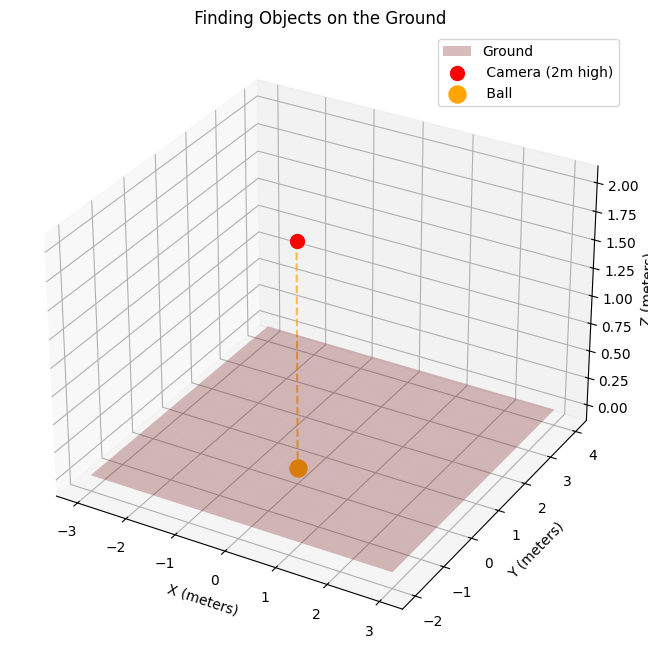

In [7]:
def pixel_to_3d_on_plane(u, v, plane_params, K):
    """Find 3D point when we know it's on a plane"""
    a, b, c, d = plane_params  # Plane equation: ax + by + cz + d = 0

    fx, fy = K[0,0], K[1,1]
    cx, cy = K[0,2], K[1,2]

    # Convert to normalized coordinates
    u_norm = (u - cx) / fx
    v_norm = (v - cy) / fy

    # Solve for Z using the plane constraint
    Z = -d / (a * u_norm + b * v_norm + c)

    # Calculate X and Y
    X = u_norm * Z
    Y = v_norm * Z

    return X, Y, Z

# Example: A ball sitting on the ground (ground is at Z = 0)
ground_plane = [0, 0, 1, 0]  # Plane equation: z = 0

# Pick a pixel where we see the ball
ball_u, ball_v = 350, 400

X, Y, Z = pixel_to_3d_on_plane(ball_u, ball_v, ground_plane, K)

print(f"⚽ Ball on the ground:")
print(f"   Position: ({X:.2f}, {Y:.2f}, {Z:.2f}) meters")

# Create a scene
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Draw the ground plane
xx, yy = np.meshgrid(np.linspace(-3, 3, 10), np.linspace(-2, 4, 10))
zz = np.zeros_like(xx)  # Ground at z=0
ax.plot_surface(xx, yy, zz, alpha=0.3, color='brown', label='Ground')

# Camera and ball
ax.scatter(0, 0, 2, color='red', s=100, label=' Camera (2m high)')
ax.scatter(X, Y, Z, color='orange', s=150, label=' Ball')

# Show the line of sight
ax.plot([0, X], [0, Y], [2, Z], 'orange', linestyle='--', alpha=0.7)

ax.set_xlabel('X (meters)')
ax.set_ylabel('Y (meters)')
ax.set_zlabel('Z (meters)')
ax.set_title(' Finding Objects on the Ground')
ax.legend()
plt.show()

---

## Chapter 6: The Ray - When We Don't Know Enough

Sometimes we just don't have enough information. But that's okay! We can still describe all the possible locations as a ray.


🌟 Mystery object at pixel (500, 200)
   Ray direction: (0.219, -0.049, 0.974)


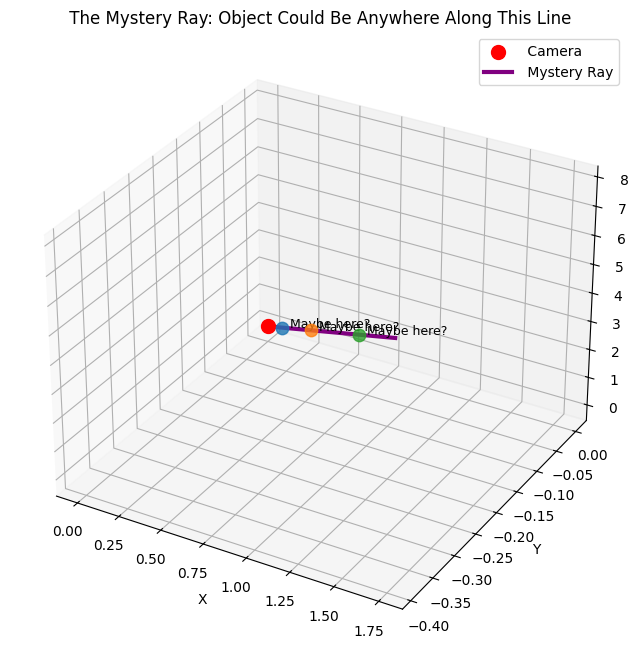


 The ray tells us: 'The object is somewhere along this line!'


In [8]:
def pixel_to_ray(u, v, K):
    """Convert pixel to a 3D ray direction"""
    fx, fy = K[0,0], K[1,1]
    cx, cy = K[0,2], K[1,2]

    # Normalized coordinates
    x_norm = (u - cx) / fx
    y_norm = (v - cy) / fy

    # Ray direction (we normalize it to make it a unit vector)
    ray_dir = np.array([x_norm, y_norm, 1.0])
    ray_dir = ray_dir / np.linalg.norm(ray_dir)

    return ray_dir

# Let's create a ray for a mysterious object
mystery_u, mystery_v = 500, 200
ray_direction = pixel_to_ray(mystery_u, mystery_v, K)

print(f"🌟 Mystery object at pixel ({mystery_u}, {mystery_v})")
print(f"   Ray direction: ({ray_direction[0]:.3f}, {ray_direction[1]:.3f}, {ray_direction[2]:.3f})")

# Visualize the ray
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Camera
ax.scatter(0, 0, 0, color='red', s=100, label=' Camera')

# Create points along the ray
distances = np.linspace(0.5, 8, 20)
ray_points = np.array([dist * ray_direction for dist in distances])

ax.plot(ray_points[:, 0], ray_points[:, 1], ray_points[:, 2],
        'purple', linewidth=3, label=' Mystery Ray')

# Show some possible locations
for i, dist in enumerate([1, 3, 6]):
    point = dist * ray_direction
    ax.scatter(*point, s=80, alpha=0.8)
    ax.text(point[0], point[1], point[2], f'  Maybe here?', fontsize=9)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title(' The Mystery Ray: Object Could Be Anywhere Along This Line')
ax.legend()
plt.show()

print("\n The ray tells us: 'The object is somewhere along this line!'")

---

## Chapter 7: The Stereo Solution - Two Eyes Are Better Than One

Just like humans have two eyes to see depth, we can use two cameras! When we see the same object in both cameras, we can find exactly where it is.


/tmp/ipython-input-10-1136670452.py:41: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


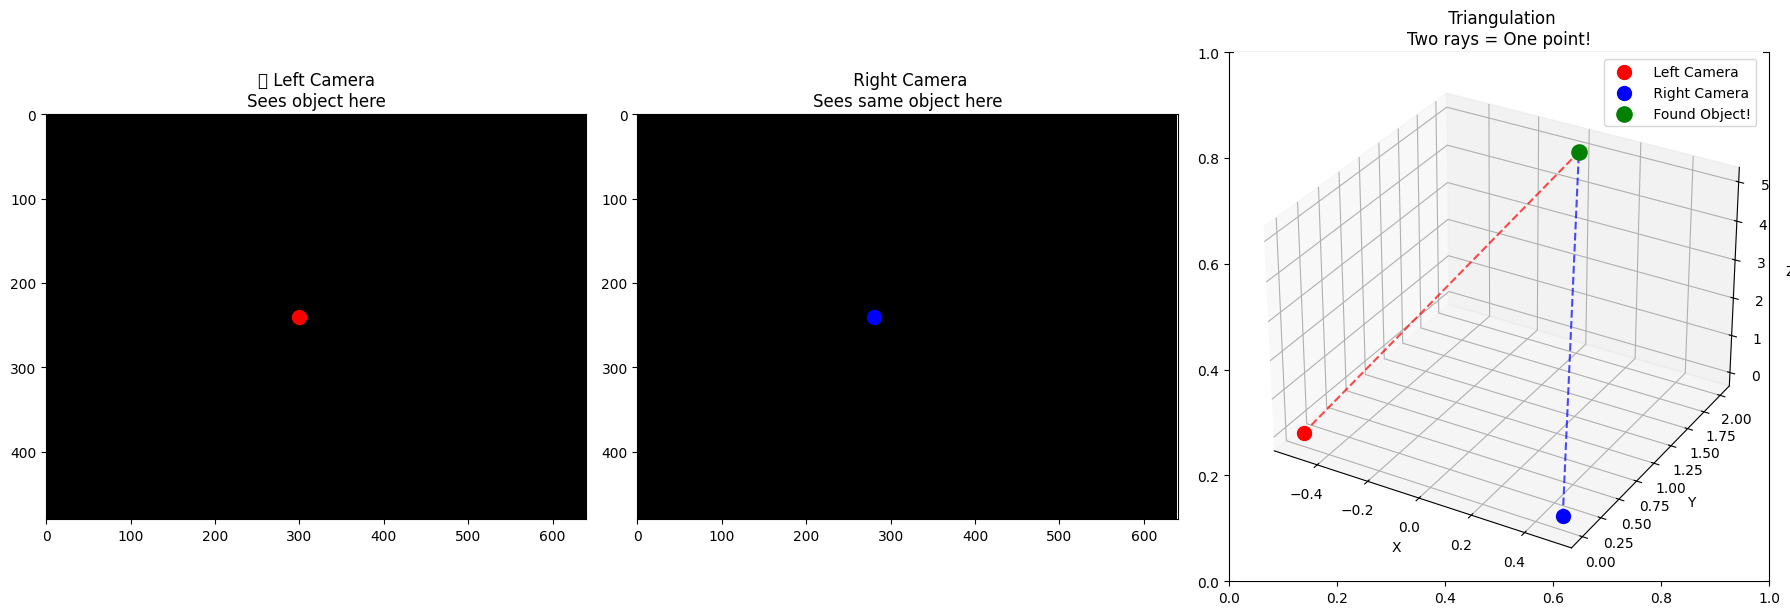

🎉 With two cameras, we can find the exact 3D location!
   This is how our eyes work too!


In [10]:
# Simulate stereo vision
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Left camera view
axes[0].imshow(np.zeros((480, 640)), cmap='gray')
left_u, left_v = 300, 240
axes[0].plot(left_u, left_v, 'ro', markersize=10)
axes[0].set_title('📷 Left Camera\nSees object here')
axes[0].set_xlim(0, 640)
axes[0].set_ylim(480, 0)

# Right camera view
axes[1].imshow(np.zeros((480, 640)), cmap='gray')
right_u, right_v = 280, 240  # Slightly different position
axes[1].plot(right_u, right_v, 'bo', markersize=10)
axes[1].set_title(' Right Camera\nSees same object here')
axes[1].set_xlim(0, 640)
axes[1].set_ylim(480, 0)

# 3D result
ax3d = plt.subplot(133, projection='3d')

# Two cameras
ax3d.scatter(-0.5, 0, 0, color='red', s=100, label=' Left Camera')
ax3d.scatter(0.5, 0, 0, color='blue', s=100, label=' Right Camera')

# The triangulated point (simplified calculation)
object_3d = np.array([0, 2, 5])
ax3d.scatter(*object_3d, color='green', s=120, label=' Found Object!')

# Draw lines from cameras to object
ax3d.plot([-0.5, object_3d[0]], [0, object_3d[1]], [0, object_3d[2]], 'r--', alpha=0.7)
ax3d.plot([0.5, object_3d[0]], [0, object_3d[1]], [0, object_3d[2]], 'b--', alpha=0.7)

ax3d.set_xlabel('X')
ax3d.set_ylabel('Y')
ax3d.set_zlabel('Z')
ax3d.set_title(' Triangulation\nTwo rays = One point!')
ax3d.legend()

plt.tight_layout()
plt.show()

print("🎉 With two cameras, we can find the exact 3D location!")
print("   This is how our eyes work too!")

--

## Chapter 8: The Complete Toolkit

Let's put it all together! Here's your complete toolkit for converting 2D pixels to 3D points:


In [11]:
class PixelTo3D:
    """Your complete pixel-to-3D conversion toolkit"""

    def __init__(self, K):
        self.K = K
        self.fx, self.fy = K[0,0], K[1,1]
        self.cx, self.cy = K[0,2], K[1,2]

    def with_known_depth(self, u, v, Z):
        """Method 1: When you know how far away the object is"""
        X = (u - self.cx) * Z / self.fx
        Y = (v - self.cy) * Z / self.fy
        return np.array([X, Y, Z])

    def on_plane(self, u, v, plane_params):
        """Method 2: When the object is on a known surface"""
        a, b, c, d = plane_params
        u_norm = (u - self.cx) / self.fx
        v_norm = (v - self.cy) / self.fy
        Z = -d / (a * u_norm + b * v_norm + c)
        X = u_norm * Z
        Y = v_norm * Z
        return np.array([X, Y, Z])

    def to_ray(self, u, v):
        """Method 3: When you don't have enough info - make a ray"""
        u_norm = (u - self.cx) / self.fx
        v_norm = (v - self.cy) / self.fy
        ray_dir = np.array([u_norm, v_norm, 1.0])
        return ray_dir / np.linalg.norm(ray_dir)

    def point_on_ray(self, u, v, distance):
        """Get a specific point along the ray"""
        ray_dir = self.to_ray(u, v)
        return distance * ray_dir

# Test our toolkit!
converter = PixelTo3D(K)

test_pixel = (400, 300)
print(f"🧪 Testing pixel {test_pixel}:")
print()

# Test each method
point1 = converter.with_known_depth(*test_pixel, Z=3.0)
print(f"Method 1 (known depth): {point1}")

ground = [0, 0, 1, 0]  # Ground plane
point2 = converter.on_plane(*test_pixel, ground)
print(f"Method 2 (on ground): {point2}")

ray = converter.to_ray(*test_pixel)
print(f"Method 3 (ray direction): {ray}")

point3 = converter.point_on_ray(*test_pixel, distance=4.0)
print(f"Method 3 (point at 4m): {point3}")

🧪 Testing pixel (400, 300):

Method 1 (known depth): [0.3   0.225 3.   ]
Method 2 (on ground): [0. 0. 0.]
Method 3 (ray direction): [0.09922779 0.07442084 0.99227788]
Method 3 (point at 4m): [0.39691115 0.29768336 3.96911151]



---

## Chapter 9: The End of Our Journey

We started with a simple question: "Where is that bird in the real world?"

Now we know the answer depends on what else we know:
- 🎯 **Know the distance?** → We can find the exact 3D point
- 🏠 **Know it's on a surface?** → We can find the exact 3D point  
- 🤷 **Don't know anything else?** → We can describe all possibilities as a ray
- 👀 **Have two cameras?** → We can triangulate the exact location


The mystery is solved! Every time you take a photo, your camera is doing this math behind the scenes. And now you know the secret too! 📸✨

---

*Thanks for joining this journey from pixels to the real world! 🚀*